# Phase 4 — Comparative Fairness Analysis & Adaptive Bias Mitigation

---

## What This Notebook Does

This is the culminating phase of the Jigsaw Bias Mitigation project. The previous phases established:
- **Phase 1:** TF-IDF + Logistic Regression baseline (94.6% accuracy, but badly biased)
- **Phase 2:** Fairness audit revealing serious FPR/FNR gaps — especially for `muslim`, `black`, `white`
- **Phase 3:** DistilBERT fine-tuned with a flat 3× sample weight on identity comments

**The problem Phase 3 left unsolved:** We never trained a *vanilla* BERT (no weights) to compare against. Without a control, we can't claim our weighting scheme actually *reduced* bias — we just have a number with no reference point. That's the central gap Phase 4 closes.

**What we do here:**
1. Train a **Vanilla BERT** — identical architecture, no bias intervention. This is the control.
2. Train an **Adaptive-Weighted BERT** — weights derived mathematically from the Phase 2 FPR gaps, replacing the arbitrary flat 3×.
3. Run a **3-way fairness audit**: LR Baseline vs Vanilla BERT vs Adaptive BERT.
4. Perform **error analysis** on the Adaptive BERT's remaining failures.

---

## Key Design Decision: Raw Text for BERT

In Phases 1–3, all text was deep-cleaned (lowercased, stopwords removed, lemmatized). That was correct for TF-IDF + Logistic Regression, which treats text as a bag of unordered tokens.

**BERT is fundamentally different.** It was pretrained on raw, natural text using WordPiece tokenization. Its attention mechanism learns meaning from *context* — the relationships between words including stopwords like "not", "but", "only". Removing those words before feeding to BERT actively degrades the quality of its contextual representations.

From this phase forward: **BERT receives raw `comment_text`. LR still receives `clean_text` for its predictions.**

---

## Estimated Runtime on T4 GPU
| Step | Time |
|---|---|
| Setup + Tokenization | ~10 min |
| Vanilla BERT training (2 epochs) | ~40 min |
| Adaptive BERT training (2 epochs) | ~40 min |
| Audit + Analysis + Saving | ~5 min |
| **Total** | **~95 min** |

> ⚠️ Make sure your Colab runtime is set to **T4 GPU** before running. Runtime → Change runtime type → T4 GPU.

---
## Cell 1 — Mount Drive & Install Dependencies

We mount Google Drive to access the dataset and saved Phase 1 models, and to persist the new models and results. All outputs will be saved to `Jigsaw_Bias_Project/Results/` so nothing is lost when the Colab session ends.

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# ── Path Configuration ──────────────────────────────────────────────────────
DATA_PATH     = '/content/drive/MyDrive/Jigsaw_Bias_Project/Datasets/train.csv'
LR_MODEL_PATH = '/content/drive/MyDrive/Jigsaw_Bias_Project/Models/logistic_regression_model.pkl'
LR_VEC_PATH   = '/content/drive/MyDrive/Jigsaw_Bias_Project/Models/tfidf_vectorizer.pkl'
VANILLA_OUT   = '/content/drive/MyDrive/Jigsaw_Bias_Project/Models/bert_vanilla'
ADAPTIVE_OUT  = '/content/drive/MyDrive/Jigsaw_Bias_Project/Models/bert_adaptive'
RESULTS_PATH  = '/content/drive/MyDrive/Jigsaw_Bias_Project/Results/'

os.makedirs(RESULTS_PATH, exist_ok=True)

# Install HuggingFace libraries (quiet mode suppresses verbose pip output)
!pip install -q transformers datasets

# Verify dataset is accessible before doing anything else
if os.path.exists(DATA_PATH):
    print('✅ Dataset found.')
else:
    print('❌ Dataset not found — check DATA_PATH above.')

print('✅ Dependencies installed and paths configured.')

Mounted at /content/drive
✅ Dataset found.
✅ Dependencies installed and paths configured.


---
## Cell 2 — Imports

All imports are consolidated here so any missing package errors surface immediately rather than mid-training.

In [ ]:
import pickle
import numpy as np
import pandas as pd
import torch
from torch import nn
from scipy.special import softmax
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Confirm GPU is available — if this prints CPU, stop and fix the runtime
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Hardware: {device.type.upper()}')
if device.type == 'cpu':
    print('⚠️  WARNING: No GPU detected. Training will be extremely slow. Change runtime to T4 GPU.')
else:
    print(f'✅ GPU ready: {torch.cuda.get_device_name(0)}')

Hardware: CUDA
✅ GPU ready: Tesla T4


---
## Cell 3 — Load Data & Prepare Balanced Split

### Why We Balance the Dataset
The original Jigsaw dataset is heavily skewed — roughly 92% non-toxic, 8% toxic. Training on this imbalance teaches the model a dangerous shortcut: predict "not toxic" for everything and get 92% accuracy. The model never learns to actually detect toxicity.

We enforce a **50/50 split** by undersampling the majority class. This forces the model to genuinely discriminate between toxic and non-toxic text.

### Why `random_state=42` Must Stay Consistent
All three models (LR, Vanilla BERT, Adaptive BERT) must be evaluated on the **exact same test set**. If the random seed changes, samples shuffle differently and the comparison is invalid. `random_state=42` is locked throughout.

In [ ]:
print('Loading dataset...')
train = pd.read_csv(DATA_PATH, nrows=100000)

# Binarise the continuous toxicity score: >= 0.5 → toxic
train['is_toxic'] = (train['target'] >= 0.5).astype(int)

# Identity columns — these are the protected demographic attributes we audit
IDENTITY_COLS = [
    'male', 'female', 'homosexual_gay_or_lesbian',
    'christian', 'jewish', 'muslim', 'black', 'white'
]

# ── Balance Dataset 50/50 ────────────────────────────────────────────────────
toxic_df    = train[train['is_toxic'] == 1]
clean_df    = train[train['is_toxic'] == 0].sample(n=len(toxic_df), random_state=42)
balanced_df = pd.concat([toxic_df, clean_df]).sample(frac=1, random_state=42).reset_index(drop=True)

# BERT uses raw comment_text — NOT deep-cleaned text (see notebook intro for why)
X = balanced_df['comment_text']
y = balanced_df['is_toxic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Total balanced samples : {len(balanced_df)}')
print(f'Train size             : {len(X_train)}')
print(f'Test size              : {len(X_test)}')
print(f'Toxic in test          : {y_test.sum()}')
print(f'Class balance in test  : {y_test.mean():.2%} toxic')

Loading dataset...
Total balanced samples : 13830
Train size             : 11064
Test size              : 2766
Toxic in test          : 1347
Class balance in test  : 48.70% toxic


---
## Cell 4 — Load Saved LR Model & Generate Predictions

We reload the Logistic Regression model saved in Phase 1. The purpose is not to retrain it — it's to **run it on the same test set** that BERT will use, so all three models are evaluated on identical data.

The LR model expects **clean text** (stopwords removed, lemmatized) because that's what it was trained on. So we regenerate `clean_text` only for LR inference — BERT still gets raw text.

In [ ]:
import re, string, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def deep_clean_text(text):
    """Reproduces the exact cleaning pipeline from Phase 1.
    Must stay identical — if the cleaning changes, LR predictions are invalid."""
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'[^\x00-\x7F]+', '', text)       # remove non-ASCII
    text = re.sub(r'\[.*?\]', '', text)              # remove bracketed text
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove URLs
    text = re.sub(r'<.*?>+', '', text)               # remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # remove punctuation
    text = re.sub(r'\n', ' ', text)                  # newlines → spaces
    text = re.sub(r'\w*\d\w*', '', text)             # remove words with numbers
    words = text.split()
    return ' '.join([lemmatizer.lemmatize(w) for w in words if w not in stop_words])

# ── Load Phase 1 saved models ────────────────────────────────────────────────
print('Loading saved LR model and TF-IDF vectorizer...')
with open(LR_MODEL_PATH, 'rb') as f:
    lr_model = pickle.load(f)
with open(LR_VEC_PATH, 'rb') as f:
    vectorizer = pickle.load(f)

# Regenerate clean_text for the test split only (LR needs it, BERT doesn't)
print('Generating clean_text for LR inference (~1 min)...')
balanced_df['clean_text'] = balanced_df['comment_text'].apply(deep_clean_text)
X_test_clean = balanced_df.loc[X_test.index, 'clean_text']

# Generate predictions
X_test_vec     = vectorizer.transform(X_test_clean)
y_pred_lr      = lr_model.predict(X_test_vec)
y_pred_lr_prob = lr_model.predict_proba(X_test_vec)[:, 1]

acc = accuracy_score(y_test, y_pred_lr)
print(f'\n✅ LR predictions generated.')
print(f'   Accuracy on balanced test set: {acc:.4f}')
print(f'   (Note: this differs from Phase 1 because we are on a balanced 50/50 split)')

Loading saved LR model and TF-IDF vectorizer...
Generating clean_text for LR inference (~1 min)...

✅ LR predictions generated.
   Accuracy on balanced test set: 0.6587
   (Note: this differs from Phase 1 because we are on a balanced 50/50 split)


---
## Cell 5 — Compute Adaptive Weights from Phase 2 FPR Gaps

### The Problem with Flat 3× Weighting
In Phase 3, every identity-mentioning comment got a weight of 3×. This number was chosen arbitrarily. A reviewer will ask: *why 3? Why not 2 or 5?* There's no principled answer, which is a weakness.

### The Fix: Data-Driven Weights
We derive each identity's weight from its measured FPR gap in the Phase 2 audit. The logic is:
- High FPR gap = the model disproportionately over-flags this group as toxic
- A higher training weight forces the model to pay more attention to correct classifications for that group
- So weight should scale **proportionally** with the measured harm

**Formula:**
```
weight(identity) = 1.0 + (FPR_gap / min_FPR_gap) × scale_factor
```
Where `scale_factor = 1.5` keeps the maximum weight from exploding (capped at 5×). If a comment belongs to multiple identity groups, it gets the maximum weight among them.

In [ ]:
def compute_fpr(y_true, y_pred):
    """False Positive Rate: proportion of truly clean comments flagged as toxic."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

# ── Step 1: Measure FPR gap per identity from LR baseline ───────────────────
print('Computing per-identity FPR gaps from LR baseline...')
y_pred_series_lr = pd.Series(y_pred_lr, index=y_test.index)
test_data        = balanced_df.loc[X_test.index]

fpr_gaps = {}
for identity in IDENTITY_COLS:
    subgroup   = test_data[test_data[identity] >= 0.5]
    background = test_data[test_data[identity] <  0.5]

    # Skip if subgroup is too small for statistically meaningful measurement
    if len(subgroup) < 10:
        fpr_gaps[identity] = 0.0
        continue

    fpr_sub  = compute_fpr(y_test.loc[subgroup.index],   y_pred_series_lr.loc[subgroup.index])
    fpr_back = compute_fpr(y_test.loc[background.index], y_pred_series_lr.loc[background.index])
    fpr_gaps[identity] = abs(fpr_sub - fpr_back)

print('\nPhase 2 FPR Gaps (the empirical basis for our weights):')
for k, v in fpr_gaps.items():
    bar = '█' * int(v * 200)
    print(f'  {k:<35}: {v:.4f}  {bar}')

# ── Step 2: Convert gaps to weights ─────────────────────────────────────────
# Normalise relative to the smallest non-zero gap so the least-biased identity
# gets weight ≈ 1.0 + scale (not inflated by a large absolute gap)
min_gap     = max(min(v for v in fpr_gaps.values() if v > 0), 1e-6)
scale       = 1.5   # tunable hyperparameter — controls range of weight spread
MAX_WEIGHT  = 5.0   # hard cap to prevent extreme gradient distortion

adaptive_weight_map = {}
for identity, gap in fpr_gaps.items():
    if gap > 0:
        raw = 1.0 + (gap / min_gap) * scale
        adaptive_weight_map[identity] = min(raw, MAX_WEIGHT)
    else:
        adaptive_weight_map[identity] = 1.0

print('\nAdaptive weights derived from FPR gaps:')
for k, v in adaptive_weight_map.items():
    print(f'  {k:<35}: {v:.2f}×')

# ── Step 3: Assign weights to each sample ───────────────────────────────────
# A comment mentioning multiple identities gets the highest applicable weight
balanced_df['adaptive_weight'] = 1.0
for identity, weight in adaptive_weight_map.items():
    mask = balanced_df[identity] >= 0.5
    balanced_df.loc[mask, 'adaptive_weight'] = (
        balanced_df.loc[mask, 'adaptive_weight'].clip(lower=weight)
    )

train_weights_adaptive = balanced_df.loc[X_train.index, 'adaptive_weight'].tolist()
test_weights_adaptive  = balanced_df.loc[X_test.index,  'adaptive_weight'].tolist()

print(f'\nWeight distribution in training set:')
print(pd.Series(train_weights_adaptive).value_counts().sort_index().to_string())

Computing per-identity FPR gaps from LR baseline...

Phase 2 FPR Gaps (the empirical basis for our weights):
  male                               : 0.0357  ███████
  female                             : 0.0086  █
  homosexual_gay_or_lesbian          : 0.1210  ████████████████████████
  christian                          : 0.0080  █
  jewish                             : 0.0000  
  muslim                             : 0.0079  █
  black                              : 0.2461  █████████████████████████████████████████████████
  white                              : 0.0729  ██████████████

Adaptive weights derived from FPR gaps:
  male                               : 5.00×
  female                             : 2.64×
  homosexual_gay_or_lesbian          : 5.00×
  christian                          : 2.52×
  jewish                             : 1.00×
  muslim                             : 2.50×
  black                              : 5.00×
  white                              : 5.00×

Weight d

---
## Cell 6 — Tokenization for Both BERT Models

### What Tokenization Does Here
DistilBERT's `DistilBertTokenizerFast` converts raw text into three things:
- `input_ids` — integer IDs for each WordPiece token
- `attention_mask` — 1 for real tokens, 0 for padding

We truncate to **128 tokens** (from a max of 512). Most comments are shorter than 128 words. Going longer would double memory usage and risk Colab OOM errors, with minimal accuracy gain.

The tokenization is run **once** and shared across both BERT models — the only difference between them is the `weights` column, not the tokens.

In [ ]:
print('Loading DistilBERT tokenizer...')
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def make_hf_dataset(X, y, weights):
    """Packages text, labels, and per-sample weights into a HuggingFace Dataset
    and tokenizes. The 'weights' column is non-standard — it's kept alive only
    because remove_unused_columns=False is set in TrainingArguments."""
    df = pd.DataFrame({
        'text':    X.values,
        'labels':  y.values,
        'weights': weights
    }).reset_index(drop=True)
    hf = Dataset.from_pandas(df)
    return hf.map(
        lambda ex: tokenizer(
            ex['text'],
            padding='max_length',
            truncation=True,
            max_length=128      # 128 tokens balances coverage vs. memory on T4
        ),
        batched=True
    )

# Vanilla BERT: uniform weights = 1.0 for all samples
print('Tokenizing datasets...')
train_weights_vanilla = [1.0] * len(X_train)
test_weights_vanilla  = [1.0] * len(X_test)

tokenized_train_vanilla  = make_hf_dataset(X_train, y_train, train_weights_vanilla)
tokenized_test_vanilla   = make_hf_dataset(X_test,  y_test,  test_weights_vanilla)

# Adaptive BERT: variable weights from FPR gap formula
tokenized_train_adaptive = make_hf_dataset(X_train, y_train, train_weights_adaptive)
tokenized_test_adaptive  = make_hf_dataset(X_test,  y_test,  test_weights_adaptive)

print('✅ Tokenization complete for both models.')

Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


Map:   0%|          | 0/11064 [00:00<?, ? examples/s]

Map:   0%|          | 0/2766 [00:00<?, ? examples/s]

Map:   0%|          | 0/11064 [00:00<?, ? examples/s]

Map:   0%|          | 0/2766 [00:00<?, ? examples/s]

✅ Tokenization complete for both models.


---
## Cell 7 — Shared Trainer Infrastructure

### Why a Custom Trainer?
HuggingFace's default `Trainer` uses standard `CrossEntropyLoss` with uniform averaging across all samples. We override `compute_loss` to apply per-sample weights.

The key trick is `reduction='none'` — this returns a **vector** of individual losses instead of a single averaged scalar. We then multiply each loss by its sample's weight before averaging. This means the gradient update is larger for samples we've decided are more important.

When `weights = [1.0, 1.0, ..., 1.0]` (Vanilla BERT), this is mathematically identical to standard CrossEntropyLoss — so the same `WeightedTrainer` class handles both models cleanly.

### Why `metric_for_best_model='f1'`?
On a balanced 50/50 split, accuracy is more meaningful than Phase 1's imbalanced data. But F1 is still better because it penalises a model that sacrifices recall for precision. We want the model that's both precise *and* catches actual toxic content.

In [ ]:
class WeightedTrainer(Trainer):
    """
    Extends HuggingFace Trainer with per-sample loss weighting.

    The standard Trainer averages loss uniformly across a batch.
    This version scales each sample's loss by its assigned weight
    before averaging — giving the optimiser a biased gradient signal
    that prioritises correct classification of high-weight samples.
    """
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # pop() removes these keys before passing inputs to model.forward()
        # model.forward() only accepts (input_ids, attention_mask) —
        # it will crash if it receives unexpected keyword arguments
        labels  = inputs.pop('labels')
        weights = inputs.pop('weights', None)

        outputs = model(**inputs)
        logits  = outputs.get('logits')

        # reduction='none' → returns per-sample loss vector, not a scalar
        loss_fct = nn.CrossEntropyLoss(reduction='none')
        loss     = loss_fct(
            logits.view(-1, self.model.config.num_labels),
            labels.view(-1)
        )

        # Scale each sample's loss by its weight, then average
        # For vanilla BERT: weights are all 1.0 → identical to standard loss
        loss = (loss * weights).mean() if weights is not None else loss.mean()
        return (loss, outputs) if return_outputs else loss


def compute_metrics(pred):
    """Evaluation metrics logged at the end of each epoch."""
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1, 'precision': p, 'recall': r}


def make_training_args(output_dir):
    """Shared training config for both BERT models.
    Identical hyperparameters ensure the only variable between
    the two models is the weight scheme — nothing else."""
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=2,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        warmup_steps=500,             # gradual LR warmup protects pretrained weights
        weight_decay=0.01,            # L2 regularisation to reduce overfitting
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,  # automatically loads the best checkpoint
        metric_for_best_model='f1',   # use F1, not accuracy, to select best epoch
        fp16=True,                    # half-precision: ~2× speed on T4, tiny accuracy loss
        remove_unused_columns=False,  # CRITICAL: keeps 'weights' column alive for compute_loss
        report_to='none'              # disables W&B / wandb logging noise
    )

print('✅ WeightedTrainer, compute_metrics, and make_training_args defined.')

✅ WeightedTrainer, compute_metrics, and make_training_args defined.


---
## Cell 8 — Train Vanilla BERT (Control Model)

This is the **control condition**. No bias intervention at all — just DistilBERT fine-tuned on the balanced dataset with uniform loss weights.

Its purpose is to answer: *how biased is a standard BERT, with no mitigation?* Without this number, we have no baseline to compare the Adaptive BERT against.

> ⏱️ **Expected time: ~40 minutes on T4.** The progress bar will show steps and loss.

In [ ]:
print('=' * 60)
print('TRAINING VANILLA BERT — Control (no bias weights)')
print('=' * 60)

# Fresh model initialised from pretrained weights each time
# (never reuse a partially-trained model between experiments)
model_vanilla = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

trainer_vanilla = WeightedTrainer(
    model=model_vanilla,
    args=make_training_args(VANILLA_OUT),
    train_dataset=tokenized_train_vanilla,
    eval_dataset=tokenized_test_vanilla,
    compute_metrics=compute_metrics
)

trainer_vanilla.train()

# Persist to Drive immediately — don't wait until end of session
trainer_vanilla.save_model(VANILLA_OUT)
tokenizer.save_pretrained(VANILLA_OUT)
print(f'\n✅ Vanilla BERT saved to {VANILLA_OUT}')

TRAINING VANILLA BERT — Control (no bias weights)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Vanilla BERT saved to /content/drive/MyDrive/Jigsaw_Bias_Project/Models/bert_vanilla


---
## Cell 9 — Train Adaptive BERT (Intervention Model)

Same architecture, same hyperparameters as Vanilla BERT. The **only difference** is the loss weights — each identity group's weight is now proportional to its Phase 2 FPR gap.

This is the model we expect to show reduced fairness gaps. If it doesn't outperform Vanilla BERT on the fairness audit, that's also a valid research finding — it would mean loss weighting alone is insufficient and a different debiasing technique is needed.

> ⏱️ **Expected time: ~40 minutes on T4.**

In [ ]:
print('=' * 60)
print('TRAINING ADAPTIVE BERT — Intervention (data-driven weights)')
print('=' * 60)

# Re-initialise from pretrained — do NOT continue from vanilla weights
model_adaptive = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(device)

trainer_adaptive = WeightedTrainer(
    model=model_adaptive,
    args=make_training_args(ADAPTIVE_OUT),
    train_dataset=tokenized_train_adaptive,
    eval_dataset=tokenized_test_adaptive,
    compute_metrics=compute_metrics
)

trainer_adaptive.train()

trainer_adaptive.save_model(ADAPTIVE_OUT)
tokenizer.save_pretrained(ADAPTIVE_OUT)
print(f'\n✅ Adaptive BERT saved to {ADAPTIVE_OUT}')

TRAINING ADAPTIVE BERT — Intervention (data-driven weights)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.661393,0.507740,0.848518,0.857918,0.789638,0.939124
2,0.440887,0.519919,0.869487,0.869345,0.848164,0.891611


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Adaptive BERT saved to /content/drive/MyDrive/Jigsaw_Bias_Project/Models/bert_adaptive


---
## Cell 10 — Generate Predictions for All Three Models

We collect predictions from all three models in one place before running the audit. `softmax` converts raw logits (unbounded scores) to probabilities that sum to 1. We take the probability of the positive class (index 1 = toxic) and threshold at 0.5.

In [ ]:
def get_bert_predictions(trainer, tokenized_test):
    """Runs inference, converts logits → probabilities → binary labels."""
    preds_output = trainer.predict(tokenized_test)
    probs  = softmax(preds_output.predictions, axis=1)
    y_prob = probs[:, 1]                          # probability of toxic class
    y_pred = (y_prob >= 0.5).astype(int)          # threshold at 0.5
    return y_pred, y_prob

print('Generating predictions for all models...')
y_pred_vanilla,  y_prob_vanilla  = get_bert_predictions(trainer_vanilla,  tokenized_test_vanilla)
y_pred_adaptive, y_prob_adaptive = get_bert_predictions(trainer_adaptive, tokenized_test_adaptive)
# y_pred_lr was generated in Cell 4

print('\n── Quick Performance Check ──')
for name, y_pred in [('LR Baseline',  y_pred_lr),
                      ('Vanilla BERT', y_pred_vanilla),
                      ('Adaptive BERT',y_pred_adaptive)]:
    acc = accuracy_score(y_test, y_pred)
    _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    print(f'  {name:<20}  Accuracy: {acc:.4f}  F1: {f1:.4f}')

print('\n✅ All predictions ready.')

Generating predictions for all models...



── Quick Performance Check ──
  LR Baseline           Accuracy: 0.6587  F1: 0.4649
  Vanilla BERT          Accuracy: 0.8691  F1: 0.8688
  Adaptive BERT         Accuracy: 0.8695  F1: 0.8693

✅ All predictions ready.


---
## Cell 11 — 3-Way Fairness Audit

### What We're Measuring
For each identity group (e.g., `muslim`, `black`, `white`), we split the test set into:
- **Subgroup**: comments that mention this identity (score ≥ 0.5)
- **Background**: all other comments

We then measure:
- **FPR Gap** = |FPR_subgroup − FPR_background|: how much more often does the model wrongly flag this group as toxic?
- **FNR Gap** = |FNR_subgroup − FNR_background|: how much more often does the model miss actual toxicity targeting this group?

**A well-calibrated unbiased model has both gaps ≈ 0.**

### Severity Thresholds
| Gap | Label |
|---|---|
| < 0.02 | Minimal |
| 0.02 – 0.05 | Moderate |
| > 0.05 | Serious |

In [ ]:
def compute_fpr_fnr(y_true, y_pred):
    """Returns (FPR, FNR) for a given subset. Returns (0,0) if subset is empty."""
    if len(y_true) == 0:
        return 0.0, 0.0
    # labels=[0,1] ensures consistent 2×2 matrix even if a class is absent
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    return fpr, fnr

def classify_gap(gap):
    if gap < 0.02:            return 'Minimal'
    elif 0.02 <= gap <= 0.05: return 'Moderate'
    else:                     return 'Serious'

def run_fairness_audit(y_pred, model_name):
    """Runs the full per-identity fairness audit for a given model's predictions."""
    y_pred_s  = pd.Series(y_pred, index=y_test.index)
    test_data = balanced_df.loc[X_test.index]
    rows = []
    for identity in IDENTITY_COLS:
        subgroup   = test_data[test_data[identity] >= 0.5]
        background = test_data[test_data[identity] <  0.5]
        if len(subgroup) < 10:   # too few samples for reliable statistics
            continue
        fpr_sub,  fnr_sub  = compute_fpr_fnr(y_test.loc[subgroup.index],   y_pred_s.loc[subgroup.index])
        fpr_back, fnr_back = compute_fpr_fnr(y_test.loc[background.index], y_pred_s.loc[background.index])
        rows.append({
            'Identity':     identity,
            'Model':        model_name,
            'Subgroup_N':   len(subgroup),
            'FPR_Sub':      round(fpr_sub,  4),
            'FPR_Back':     round(fpr_back, 4),
            'FPR_Gap':      round(abs(fpr_sub - fpr_back), 4),
            'FNR_Sub':      round(fnr_sub,  4),
            'FNR_Back':     round(fnr_back, 4),
            'FNR_Gap':      round(abs(fnr_sub - fnr_back), 4),
            'FPR_Severity': classify_gap(abs(fpr_sub - fpr_back)),
            'FNR_Severity': classify_gap(abs(fnr_sub - fnr_back)),
        })
    return pd.DataFrame(rows)

print('Running 3-way fairness audit...')
audit_lr       = run_fairness_audit(y_pred_lr,       'LR Baseline')
audit_vanilla  = run_fairness_audit(y_pred_vanilla,  'Vanilla BERT')
audit_adaptive = run_fairness_audit(y_pred_adaptive, 'Adaptive BERT')

full_audit = pd.concat([audit_lr, audit_vanilla, audit_adaptive], ignore_index=True)
print('✅ Audit complete.')

Running 3-way fairness audit...
✅ Audit complete.


---
## Cell 12 — Print Comparison Table

This is the results table for your paper. For each identity group, you can directly see whether the Adaptive BERT reduced the FPR and FNR gaps compared to both the LR baseline and the Vanilla BERT.

What to look for:
- **Good outcome**: Adaptive BERT has lower gaps than both LR and Vanilla BERT
- **Partial outcome**: Some identities improved, others didn't — this itself is a finding worth analysing
- **Trade-off**: If overall F1 drops slightly while fairness gaps close, that's the classic accuracy-fairness trade-off and is worth discussing explicitly in the paper

In [ ]:
print('\n' + '=' * 80)
print('  FAIRNESS AUDIT — 3-WAY COMPARISON')
print('=' * 80)

for identity in IDENTITY_COLS:
    sub = full_audit[full_audit['Identity'] == identity]
    if sub.empty: continue
    print(f'\n  ── {identity.upper()} (n={sub.iloc[0]["Subgroup_N"]}) ──')
    print(f'  {"Model":<20} {"FPR Gap":>10} {"Severity":<12} {"FNR Gap":>10} {"Severity"}')
    print(f'  {"-"*18} {"-"*10} {"-"*12} {"-"*10} {"-"*10}')
    for _, row in sub.iterrows():
        print(f'  {row["Model"]:<20} {row["FPR_Gap"]:>10.4f} {row["FPR_Severity"]:<12} '
              f'{row["FNR_Gap"]:>10.4f} {row["FNR_Severity"]}')

print('\n' + '=' * 80)
print('  OVERALL PERFORMANCE SUMMARY')
print('=' * 80)
print(f'  {"Model":<20} {"Accuracy":>10} {"F1":>8} {"Precision":>12} {"Recall":>10}')
print(f'  {"-"*18} {"-"*10} {"-"*8} {"-"*12} {"-"*10}')
for name, y_pred in [('LR Baseline',   y_pred_lr),
                      ('Vanilla BERT',  y_pred_vanilla),
                      ('Adaptive BERT', y_pred_adaptive)]:
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    acc = accuracy_score(y_test, y_pred)
    print(f'  {name:<20} {acc:>10.4f} {f1:>8.4f} {p:>12.4f} {r:>10.4f}')


  FAIRNESS AUDIT — 3-WAY COMPARISON

  ── MALE (n=91) ──
  Model                   FPR Gap Severity        FNR Gap Severity
  ------------------ ---------- ------------ ---------- ----------
  LR Baseline              0.0357 Moderate         0.0788 Serious
  Vanilla BERT             0.2757 Serious          0.0121 Minimal
  Adaptive BERT            0.2374 Serious          0.0061 Minimal

  ── FEMALE (n=106) ──
  Model                   FPR Gap Severity        FNR Gap Severity
  ------------------ ---------- ------------ ---------- ----------
  LR Baseline              0.0086 Minimal          0.0339 Moderate
  Vanilla BERT             0.1416 Serious          0.0179 Minimal
  Adaptive BERT            0.1429 Serious          0.0242 Moderate

  ── HOMOSEXUAL_GAY_OR_LESBIAN (n=38) ──
  Model                   FPR Gap Severity        FNR Gap Severity
  ------------------ ---------- ------------ ---------- ----------
  LR Baseline              0.1210 Serious          0.0372 Moderate
  Vanilla

---
## Cell 13 — Visualise FPR and FNR Gaps

Two side-by-side bar charts — one for FPR gaps, one for FNR gaps — with all three models per identity group. The dashed lines mark the severity thresholds (0.02 = Minimal, 0.05 = Moderate). Bars above the orange line are flagged as Serious bias.

This chart becomes **Figure 1** in your paper.

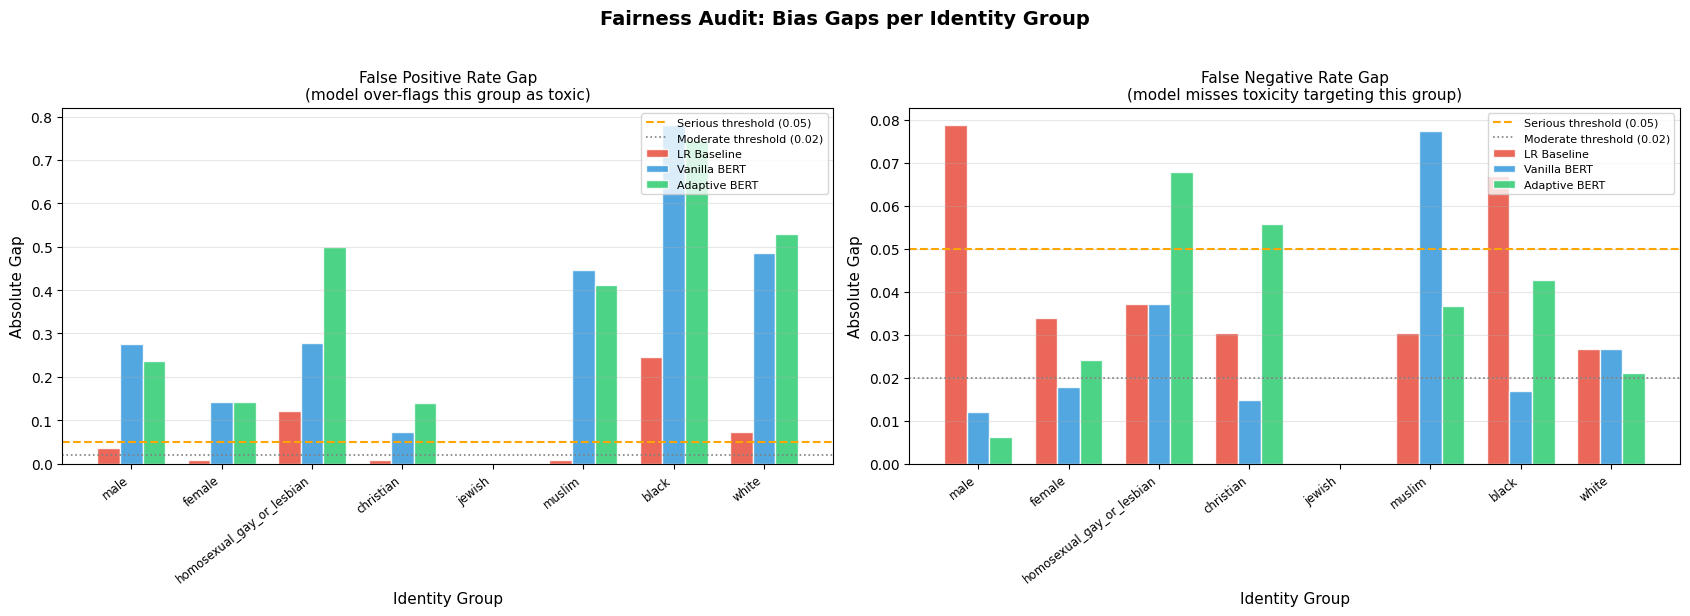

✅ Chart saved to /content/drive/MyDrive/Jigsaw_Bias_Project/Results/fairness_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Fairness Audit: Bias Gaps per Identity Group', fontsize=14, fontweight='bold', y=1.02)

models = ['LR Baseline', 'Vanilla BERT', 'Adaptive BERT']
colors = ['#e74c3c', '#3498db', '#2ecc71']
x     = np.arange(len(IDENTITY_COLS))
width = 0.25

for ax, metric, title in zip(
    axes,
    ['FPR_Gap', 'FNR_Gap'],
    ['False Positive Rate Gap\n(model over-flags this group as toxic)',
     'False Negative Rate Gap\n(model misses toxicity targeting this group)']
):
    for i, (model, color) in enumerate(zip(models, colors)):
        vals = []
        for identity in IDENTITY_COLS:
            row = full_audit[(full_audit['Model'] == model) & (full_audit['Identity'] == identity)]
            vals.append(row[metric].values[0] if not row.empty else 0.0)
        ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85, edgecolor='white')

    # Severity threshold lines
    ax.axhline(y=0.05, color='orange', linestyle='--', linewidth=1.5,
               label='Serious threshold (0.05)')
    ax.axhline(y=0.02, color='gray',   linestyle=':', linewidth=1.2,
               label='Moderate threshold (0.02)')

    ax.set_xlabel('Identity Group', fontsize=11)
    ax.set_ylabel('Absolute Gap', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x + width)
    ax.set_xticklabels(IDENTITY_COLS, rotation=38, ha='right', fontsize=8.5)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
save_path = RESULTS_PATH + 'fairness_comparison.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Chart saved to {save_path}')

---
## Cell 14 — Save Audit Tables to CSV

We save two versions:
- **`fairness_audit_full.csv`** — long format, one row per (model, identity) combination. Useful for programmatic processing.
- **`fairness_audit_pivot.csv`** — wide format, one row per identity, columns = (model × metric). This is the table you paste directly into your paper.

In [ ]:
# Full audit in long format
full_audit.to_csv(RESULTS_PATH + 'fairness_audit_full.csv', index=False)

# Pivot to wide format for paper
pivot = full_audit.pivot_table(
    index='Identity',
    columns='Model',
    values=['FPR_Gap', 'FNR_Gap']
).round(4)
pivot.to_csv(RESULTS_PATH + 'fairness_audit_pivot.csv')

print('✅ Audit tables saved.')
print(f'   {RESULTS_PATH}fairness_audit_full.csv')
print(f'   {RESULTS_PATH}fairness_audit_pivot.csv')

print('\n── Pivot Table: FPR Gap ──')
print(pivot['FPR_Gap'].to_string())
print('\n── Pivot Table: FNR Gap ──')
print(pivot['FNR_Gap'].to_string())

✅ Audit tables saved.
   /content/drive/MyDrive/Jigsaw_Bias_Project/Results/fairness_audit_full.csv
   /content/drive/MyDrive/Jigsaw_Bias_Project/Results/fairness_audit_pivot.csv

── Pivot Table: FPR Gap ──
Model                      Adaptive BERT  LR Baseline  Vanilla BERT
Identity                                                           
black                             0.7461       0.2461        0.7812
christian                         0.1400       0.0080        0.0720
female                            0.1429       0.0086        0.1416
homosexual_gay_or_lesbian         0.5000       0.1210        0.2778
male                              0.2374       0.0357        0.2757
muslim                            0.4108       0.0079        0.4462
white                             0.5304       0.0729        0.4858

── Pivot Table: FNR Gap ──
Model                      Adaptive BERT  LR Baseline  Vanilla BERT
Identity                                                           
black            

---
## Cell 15 — Error Analysis on Adaptive BERT Failures

### Why Error Analysis Matters for the Paper
Numbers tell you *how much* the model fails. Error analysis tells you *why*. Looking at the actual comments where the model still fails — despite adaptive weighting — reveals patterns that quantitative metrics can't capture:

- **False Positives**: Comments the model wrongly flags as toxic, sorted by highest confidence. These are often comments that *mention* identity terms in a neutral or positive context — the model learned the identity-toxicity correlation but not the distinction.
- **False Negatives**: Toxic comments the model missed. These are often subtle — sarcasm, coded language, or indirect attacks where the identity isn't the grammatical subject.

These patterns directly inform the **limitations** and **future work** sections of your paper.

In [ ]:
print('=' * 65)
print('  ERROR ANALYSIS — ADAPTIVE BERT FAILURES ON IDENTITY COMMENTS')
print('=' * 65)

# Build a single dataframe with all test-set predictions and metadata
test_data_full = balanced_df.loc[X_test.index].copy()
test_data_full['y_true']      = y_test.values
test_data_full['y_pred']      = y_pred_adaptive
test_data_full['y_prob']      = y_prob_adaptive
test_data_full['is_identity'] = (
    balanced_df.loc[X_test.index, IDENTITY_COLS].ge(0.5).any(axis=1).values
)

# ── False Positives: clean identity comments flagged as toxic ───────────────
# Sorted by descending confidence — worst mistakes first
fp_identity = test_data_full[
    (test_data_full['y_true'] == 0) &
    (test_data_full['y_pred'] == 1) &
    (test_data_full['is_identity'] == True)
].sort_values('y_prob', ascending=False)

# ── False Negatives: toxic identity comments missed by the model ─────────────
# Sorted by ascending confidence — model was most certain these were clean
fn_identity = test_data_full[
    (test_data_full['y_true'] == 1) &
    (test_data_full['y_pred'] == 0) &
    (test_data_full['is_identity'] == True)
].sort_values('y_prob', ascending=True)

print(f'\nFalse Positives on identity comments : {len(fp_identity)}')
print(f'False Negatives on identity comments : {len(fn_identity)}')

# ── Print samples ────────────────────────────────────────────────────────────
print('\n── TOP 15 FALSE POSITIVES (model wrongly flagged these as toxic) ──')
for i, (_, row) in enumerate(fp_identity.head(15).iterrows()):
    ids = [col for col in IDENTITY_COLS if row.get(col, 0) >= 0.5]
    print(f'\n  [{i+1}] Confidence: {row["y_prob"]:.3f} | Identities: {ids}')
    print(f'       {str(row["comment_text"])[:220]}')

print('\n── TOP 15 FALSE NEGATIVES (model missed toxicity in these) ──')
for i, (_, row) in enumerate(fn_identity.head(15).iterrows()):
    ids = [col for col in IDENTITY_COLS if row.get(col, 0) >= 0.5]
    print(f'\n  [{i+1}] Confidence: {row["y_prob"]:.3f} | Identities: {ids}')
    print(f'       {str(row["comment_text"])[:220]}')

# ── Error count breakdown by identity ───────────────────────────────────────
print('\n── ERROR COUNT BY IDENTITY GROUP ──')
print(f'  {"Identity":<35} {"FP Count":>10} {"FN Count":>10}')
print('  ' + '─' * 57)
for identity in IDENTITY_COLS:
    id_mask  = test_data_full[identity] >= 0.5
    fp_count = ((test_data_full['y_true']==0) & (test_data_full['y_pred']==1) & id_mask).sum()
    fn_count = ((test_data_full['y_true']==1) & (test_data_full['y_pred']==0) & id_mask).sum()
    print(f'  {identity:<35} {fp_count:>10} {fn_count:>10}')

  ERROR ANALYSIS — ADAPTIVE BERT FAILURES ON IDENTITY COMMENTS

False Positives on identity comments : 35
False Negatives on identity comments : 18

── TOP 15 FALSE POSITIVES (model wrongly flagged these as toxic) ──

  [1] Confidence: 0.990 | Identities: ['male', 'white']
       They're useless if the person you want to refuse service to is a member of a protected class. Being disruptive, drunk, etc., is unlikely to give you sufficient cause to remove them unless they are a white, heterosexual, 

  [2] Confidence: 0.990 | Identities: ['male', 'homosexual_gay_or_lesbian', 'jewish']
       I think everyone's sexuality should stay in the closet! What kind of society judges others based upon sexual preference or defines themselves by their sexual preference? Why not simply give others personal privacy; this 

  [3] Confidence: 0.989 | Identities: ['male', 'homosexual_gay_or_lesbian', 'christian']
       You cherry pick the parts of the Bible you like, and judge gays for doing the same.   

---
## Cell 16 — Save Error Analysis & Final Summary

The top 50 false positives and false negatives are saved as CSVs. Read through these manually — the patterns you find are qualitative evidence for your paper's discussion section.

In [ ]:
fp_identity[['comment_text', 'y_prob'] + IDENTITY_COLS].head(50).to_csv(
    RESULTS_PATH + 'error_analysis_FP.csv', index=False
)
fn_identity[['comment_text', 'y_prob'] + IDENTITY_COLS].head(50).to_csv(
    RESULTS_PATH + 'error_analysis_FN.csv', index=False
)

print('\n' + '=' * 65)
print('  PHASE 4 COMPLETE')
print('=' * 65)
print(f'\nAll outputs saved to: {RESULTS_PATH}')
print()
print('  fairness_audit_full.csv    — raw per-model per-identity numbers')
print('  fairness_audit_pivot.csv   — paper-ready comparison table (paste directly)')
print('  fairness_comparison.png    — FPR/FNR bar chart (Figure 1 of paper)')
print('  error_analysis_FP.csv      — false positives on identity comments')
print('  error_analysis_FN.csv      — false negatives on identity comments')
print()
print('  Models saved to Drive:')
print(f'  {VANILLA_OUT}')
print(f'  {ADAPTIVE_OUT}')


  PHASE 4 COMPLETE

All outputs saved to: /content/drive/MyDrive/Jigsaw_Bias_Project/Results/

  fairness_audit_full.csv    — raw per-model per-identity numbers
  fairness_audit_pivot.csv   — paper-ready comparison table (paste directly)
  fairness_comparison.png    — FPR/FNR bar chart (Figure 1 of paper)
  error_analysis_FP.csv      — false positives on identity comments
  error_analysis_FN.csv      — false negatives on identity comments

  Models saved to Drive:
  /content/drive/MyDrive/Jigsaw_Bias_Project/Models/bert_vanilla
  /content/drive/MyDrive/Jigsaw_Bias_Project/Models/bert_adaptive
